# 2.6 Adaptive RAG - Agent 버전

기존 `StateGraph` 방식은 `router → vector_store / llm / web_search`로 직접 분기했습니다.

이 버전은 `create_agent()`를 사용해서 다음처럼 동작합니다.

```text
사용자 질문 → Agent(model) → 필요하면 tool 호출 → 최종 답변
```

- 국민연금/연금법 관련 질문: `search_pension_law` tool 사용
- 최신 정보/지역 맛집/실시간 정보: `web_search` tool 사용
- 간단한 일반 질문: tool 없이 모델이 바로 답변

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_upstage import ChatUpstage
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_community.tools import TavilySearchResults

# Agent가 사용할 기본 모델입니다.
llm = ChatUpstage()

C:\Users\student\AppData\Local\Temp\ipykernel_19888\2397360545.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilySearchResults


## 1. Web Search Tool

기존 `web_search` 노드 역할을 Agent tool로 변경합니다.
Agent가 최신 정보가 필요하다고 판단하면 이 tool을 호출합니다.

In [3]:
tavily_search_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)


def format_search_results(results, max_results=3, max_chars_per_result=1500) -> str:
    """Tavily 검색 결과를 Agent tool 반환값으로 쓰기 좋은 문자열로 변환합니다.

    TavilySearchResults의 반환 형태가 버전에 따라 다를 수 있어
    list[dict], dict(results=[...]), dict(answer=..., results=[...]), str 모두 처리합니다.
    """
    if not results:
        return "검색 결과가 없습니다."

    answer = None

    if isinstance(results, dict):
        answer = results.get("answer")
        items = results.get("results") or results.get("items") or []

        if not items and any(k in results for k in ("title", "url", "content", "raw_content")):
            items = [results]

    elif isinstance(results, list):
        items = results

    else:
        return str(results)[: max_results * max_chars_per_result]

    if not items:
        if answer:
            return f"검색 요약:\n{answer}"
        return "검색 결과가 없습니다."

    formatted = []

    if answer:
        formatted.append(f"[검색 요약]\n{answer}")

    for idx, item in enumerate(items[:max_results], start=1):
        if isinstance(item, dict):
            title = item.get("title") or "제목 없음"
            url = item.get("url") or "URL 없음"
            content = (
                item.get("content")
                or item.get("raw_content")
                or item.get("snippet")
                or item.get("answer")
                or "내용 없음"
            )

            text = (
                f"[검색 결과 {idx}]\n"
                f"제목: {title}\n"
                f"URL: {url}\n"
                f"내용:\n{content}"
            )
        else:
            text = f"[검색 결과 {idx}]\n{item}"

        formatted.append(text[:max_chars_per_result])

    return "\n\n---\n\n".join(formatted)


@tool
def web_search(query: str) -> str:
    """최신 정보, 실시간 정보, 지역 맛집, 현재 이슈처럼 웹 검색이 필요한 질문에 사용합니다."""
    results = tavily_search_tool.invoke(query)
    return format_search_results(results)

C:\Users\student\AppData\Local\Temp\ipykernel_19888\1854503459.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(


## 2. Pension Law Tool

기존 Adaptive RAG에서는 `router`가 `vector_store`를 선택하면 `pesion_law_graph` 서브그래프로 이동했습니다.

Agent 버전에서는 그 서브그래프를 하나의 tool처럼 감싸서 사용합니다.

In [4]:
from pesion_law_agent import graph as pension_law_graph


@tool
def search_pension_law(query: str) -> str:
    """국민연금, 연금 수령, 사업장가입자, 지역가입자 등 국민연금 법령/문서 기반 질문에 사용합니다."""
    result = pension_law_graph.invoke({"query": query})

    # pesion_law_graph 결과 구조가 {'answer': ...} 형태라면 answer만 반환합니다.
    if isinstance(result, dict):
        return result.get("answer") or str(result)

    return str(result)

## 3. Agent 생성

기존의 `router`는 제거하고, 어떤 tool을 쓸지는 Agent가 판단하게 합니다.

In [5]:
system_prompt = """
You are an adaptive RAG assistant.

You can answer in three ways:

1. If the question is about 국민연금, pension law, 가입자 유형, 연금 수령, 보험료, 사업장가입자, 지역가입자, 임의가입자, 외국인가입자, use the search_pension_law tool.
2. If the question requires current, local, real-time, or web-based information, use the web_search tool.
3. If the question is simple and does not require retrieval or web search, answer directly without using tools.

When you use a tool, base your answer on the tool result.
If you do not know the answer, say you do not know.
Answer in Korean unless the user asks otherwise.
Keep the answer concise.
"""

agent = create_agent(
    model=llm,
    tools=[search_pension_law, web_search],
    system_prompt=system_prompt,
)

## 4. Agent 그래프 이미지 확인

`create_agent()`도 내부적으로 LangGraph 기반이므로 그래프를 확인할 수 있습니다.

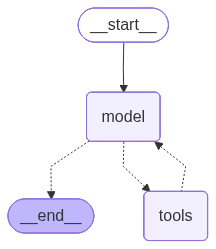

In [6]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG 출력 실패:", e)
    print(agent.get_graph().draw_mermaid())

## 5. 실행 예시

`create_agent()`는 `messages` 형식으로 입력합니다.

In [7]:
result = agent.invoke({
    "messages": [
        {"role": "user", "content": "일반적으로 직장인은 언제 연금을 수령할 수 있나요?"}
    ]
})

result

{'messages': [HumanMessage(content='일반적으로 직장인은 언제 연금을 수령할 수 있나요?', additional_kwargs={}, response_metadata={}, id='cb4b3f4d-9d57-41c2-bc1b-b5f015de35d3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 520, 'total_tokens': 593, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-mini-250422', 'system_fingerprint': None, 'id': '2112cb79-e587-4577-84bf-4847fe3f9f76', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efdd0-6e22-7570-ae78-7747d2733d10-0', tool_calls=[{'name': 'search_pension_law', 'args': {'query': '직장인 연금 수령 가능 연령'}, 'id': '0f234040-d69e-4ec9-9c58-846761328e5d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 520, 'output_tokens': 73, 'tot

In [8]:
result = agent.invoke({
    "messages": [
        {"role": "user", "content": "역삼역 맛집은?"}
    ]
})

result

{'messages': [HumanMessage(content='역삼역 맛집은?', additional_kwargs={}, response_metadata={}, id='d636cabc-398c-4da5-8342-ec3b8f5e949f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 514, 'total_tokens': 575, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-mini-250422', 'system_fingerprint': None, 'id': 'fa52e3fc-d329-412f-bb98-4b7b0825c243', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efdd1-2699-7f31-b656-23238f23a2d1-0', tool_calls=[{'name': 'web_search', 'args': {'query': '역삼역 맛집'}, 'id': '3d3b39c8-e156-4ff8-944f-2b7ab14be86d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 514, 'output_tokens': 61, 'total_tokens': 575, 'input_token_details

## 참고: 기존 StateGraph 방식과 차이

기존 방식:

```text
START → router → pension_law_agent / basic_generate / web_search → END
```

Agent 방식:

```text
START → model ↔ tools → END
```

따라서 기존처럼 `router`, `web_generate`, `basic_generate` 노드를 직접 만들 필요가 없습니다.
Agent가 모델 응답 과정에서 필요한 tool을 선택합니다.